# 07 - Ảnh hưởng đặc trưng hình học (số cạnh, độ dày) lên hệ số Poisson v12

**Nhánh B** (2026-08-09): yêu cầu gốc - "đánh giá ảnh hưởng các kết quả, ví dụ số lượng cạnh/độ dày tới hệ số Poisson's", dùng "câu nhị phân" (kiểm định nhị phân).

Khác với `analysis/sensitivity/` (đã có sẵn - đo tham số SIMP **đầu vào**: `volfrac`, `penal`, `rmin`, `void_size_frac`... → objective), notebook này đo đặc trưng **topology xuất hiện (emergent)** trong ảnh kết quả - số thanh/cạnh (struts), độ dày thanh, số mảnh liên thông - rồi kiểm định ảnh hưởng của chúng lên `v12`. Đây là khoảng trống chưa có trong pipeline.

**Phương pháp trích đặc trưng** (chỉ dùng numpy/scipy/networkx đã có sẵn trong `requirements.txt`, không cần `scikit-image`):
1. Binarize ảnh tại ngưỡng 0.5 (đúng convention `pipeline/phase5_cvae/manufacturability.py`).
2. Pad tuần hoàn (wrap) quanh biên trước khi skeleton hóa - tránh thanh bị cắt ngang bởi biên ô đơn vị tạo endpoint giả.
3. Zhang-Suen thinning (vector hóa numpy) → skeleton 1-pixel-wide.
4. Rút gọn skeleton pixel-graph thành graph topology thật (contract chuỗi pass-through) → `n_edges` (số thanh thật), `n_junctions`, `n_endpoints`.
5. Độ dày thanh = 2×distance-transform tại các pixel skeleton (proxy chuẩn cho bề rộng cục bộ dọc trục trung tuyến).

Toàn bộ hàm tái sử dụng nằm trong [`notebooks/utils.py`](utils.py) (`extract_geometric_features`, `skeleton_topology`, `zhang_suen_thin`, `analyze_geometric_group`, `binary_split_test`, `partial_corr`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path.cwd())) if (Path.cwd() / "utils.py").exists() else None
import utils

%matplotlib inline
plt.rcParams["figure.dpi"] = 110


## 1. Sanity check: skeleton có bám đúng cấu trúc không?

Trước khi tin vào bất kỳ con số thống kê nào, cần xác nhận trực quan rằng thuật toán skeleton hóa tự viết (Zhang-Suen + graph contraction, chưa từng dùng trong pipeline trước đây) bám đúng trục trung tuyến của vật liệu, không lỗi.

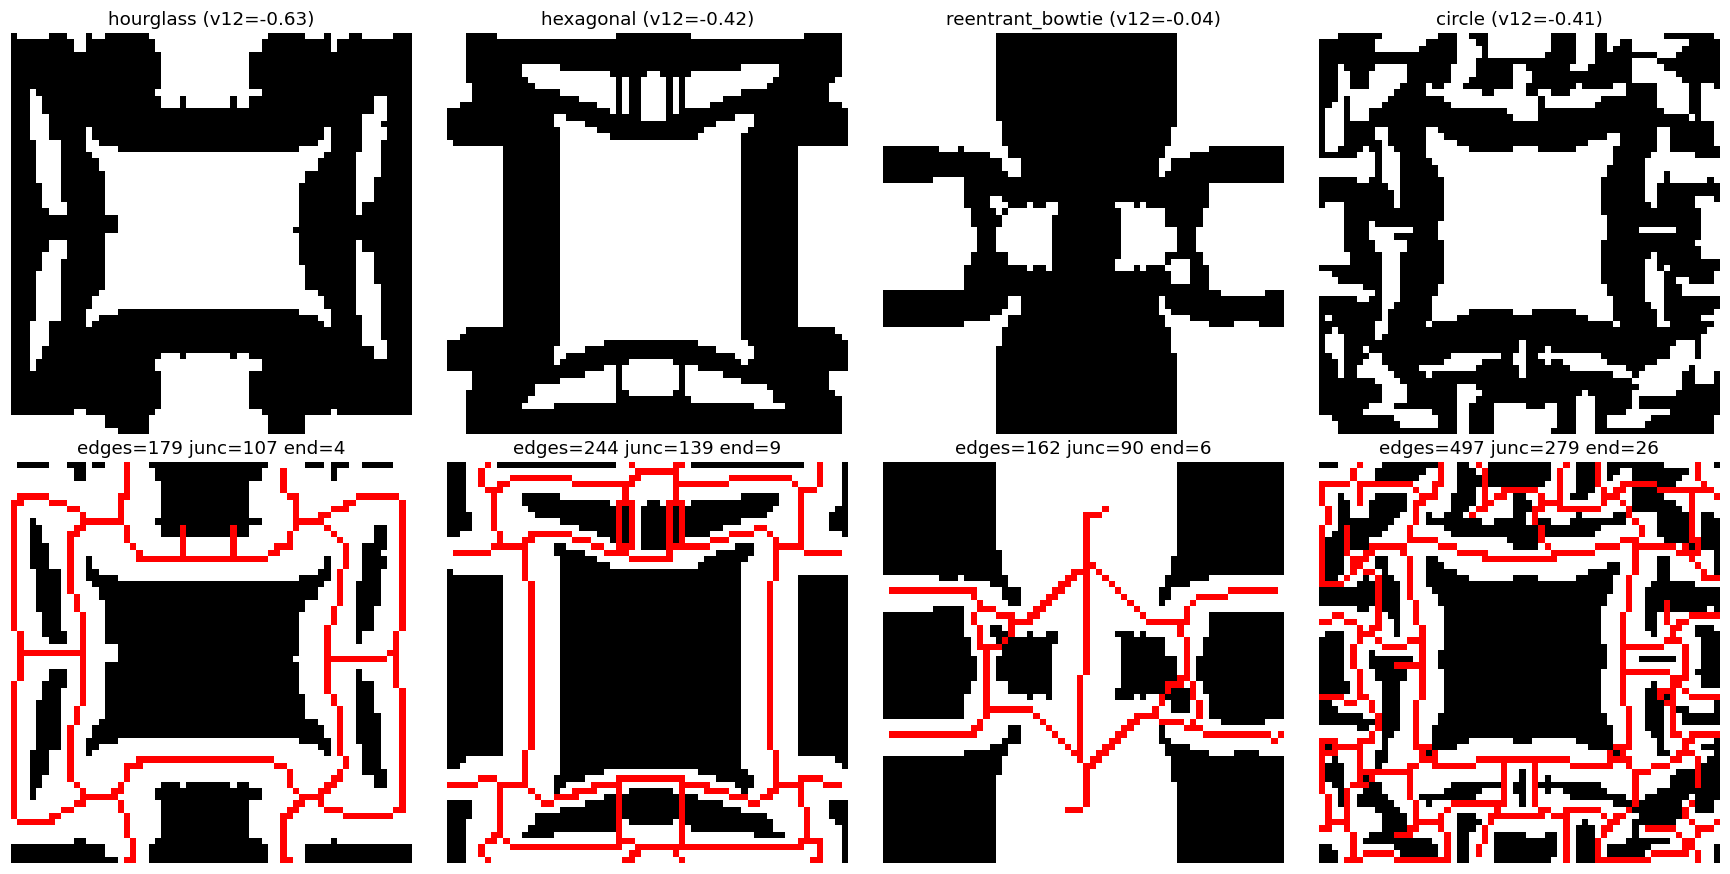

In [2]:
d = np.load(utils.PHASE3_DIR / "train_ext.npz", allow_pickle=True)
rng = np.random.default_rng(1)
targets = ["hourglass", "hexagonal", "reentrant_bowtie", "circle"]

fig, axes = plt.subplots(2, len(targets), figsize=(4 * len(targets), 8))
for j, name in enumerate(targets):
    idx = np.where(d["seed_names"] == name)[0]
    i = rng.choice(idx)
    img = d["images"][i]
    binary = img > utils.GEOM_BIN_THRESHOLD
    padded = np.pad(binary, utils.GEOM_PAD, mode="wrap")
    skel = utils.zhang_suen_thin(padded)[utils.GEOM_PAD:-utils.GEOM_PAD, utils.GEOM_PAD:-utils.GEOM_PAD]
    topo = utils.skeleton_topology(skel)

    axes[0, j].imshow(binary, cmap="gray_r")
    axes[0, j].set_title(f"{name} (v12={d['v12'][i]:.2f})")
    overlay = np.stack([binary.astype(float)] * 3, axis=-1)
    overlay[skel] = [1, 0, 0]
    axes[1, j].imshow(overlay)
    axes[1, j].set_title(f"edges={topo['n_edges']:.0f} junc={topo['n_junctions']:.0f} end={topo['n_endpoints']:.0f}")

for ax in axes.flat:
    ax.axis("off")
fig.tight_layout()
plt.show()


Skeleton (đỏ) bám đúng trục trung tuyến của vật liệu rắn ở cả 4 họ seed, junction/endpoint xuất hiện đúng chỗ có nhánh/đầu tự do. Có thể tin cậy đặc trưng trích ra.

## 2. Lấy mẫu và trích đặc trưng

Gộp `train + val + test_ext.npz` (phân tích mô tả post-hoc, không train model nên không có rủi ro leakage giữa split), lấy mẫu phân tầng theo `seed_class` - mặc định 6.000 mẫu (đủ mạnh cho kiểm định thống kê, chạy ~1 phút; đổi `n_samples=None` để dùng toàn bộ ~57k mẫu, chậm hơn nhiều).

In [3]:
meta, images = utils.load_geometric_analysis_sample(n_samples=6000, seed=0)
print(f"{len(meta)} mau, phan bo theo seed_class:")
print(meta["seed_name"].value_counts())


6001 mau, phan bo theo seed_class:
seed_name
hourglass              3121
hexagonal               933
reentrant_bowtie        503
circle                  201
cross_rectangular       198
small_square_cross      190
square                  188
nine_circle             174
grid_circular_voids     167
circle_half_quarter     166
four_circle             160
Name: count, dtype: int64


In [4]:
feat_rows = []
for img in images:
    feat_rows.append(utils.extract_geometric_features(img))
feat_df = pd.DataFrame(feat_rows)
df = pd.concat([meta.reset_index(drop=True), feat_df], axis=1)
df.head()


,idx,v12,seed_name,volfrac_param,split,n_edges,n_junctions,n_endpoints,n_isolated_specks,mean_thickness_px,std_thickness_px,skeleton_length_px,n_components,solid_frac
0,52211,-0.550078,hourglass,0.531439,train,181.0,94.0,8.0,0.0,7.334106,2.897515,379.0,1.0,0.513672
1,29887,-0.411993,hourglass,0.569546,train,174.0,92.0,4.0,0.0,8.364319,2.680299,384.0,1.0,0.556641
2,35044,-0.697115,hourglass,0.669929,train,148.0,88.0,4.0,0.0,8.467702,2.449880,385.0,1.0,0.625000
3,30755,-0.327315,circle,0.630119,train,254.0,143.0,14.0,0.0,8.922290,3.375733,353.0,1.0,0.636230
4,51988,-0.307910,grid_circular_voids,0.481814,train,380.0,215.0,11.0,0.0,4.659213,2.229334,578.0,1.0,0.478516


## 3. Thống kê ảnh hưởng

Ba phép kiểm định cho mỗi đặc trưng hình học × v12:
- **Pearson/Spearman**: hướng + độ mạnh quan hệ tuyến tính/đơn điệu.
- **Partial correlation kiểm soát `volfrac`**: vì `volfrac` gần như quyết định trực tiếp `n_edges`/`thickness` một cách tầm thường - cần tách phần ảnh hưởng THẬT của topology.
- **Kiểm định nhị phân** (đúng yêu cầu gốc "câu nhị phân"): chia mẫu theo median của từng đặc trưng thành 2 nhóm cao/thấp, Mann-Whitney U test (phi tham số) so sánh `v12` giữa 2 nhóm + effect size (rank-biserial).

Chạy trên **toàn bộ mẫu gộp (pooled)** trước, sau đó **tách theo từng `seed_class`** - vì các họ seed khác nhau chiếm vùng giá trị v12 và cấu trúc rất khác nhau, số liệu gộp có thể gây hiểu lầm (Simpson's paradox).

In [5]:
pooled = utils.analyze_geometric_group(df, "pooled_all_seeds")

print(f"=== POOLED (n={pooled['n']}) ===")
print(f"{'feature':<20} {'pearson_r':>10} {'p':>10} {'partial_r|volfrac':>18} {'binary p':>10} {'rank_bis':>10}")
for col, dd in pooled["features"].items():
    b = dd["binary_test"]
    print(f"{col:<20} {dd['pearson_r']:>10.3f} {dd['pearson_p']:>10.2e} "
          f"{dd['partial_corr_ctrl_volfrac']:>18.3f} {b['p_value']:>10.2e} {b['rank_biserial']:>10.3f}")

if "regression" in pooled:
    reg = pooled["regression"]
    print(f"\nHoi quy da bien (chuan hoa), R2={reg['r2']:.3f}:")
    for c, k in reg["standardized_coef"].items():
        print(f"  {c:<20} beta={k:+.3f}")


=== POOLED (n=6001) ===
feature               pearson_r          p  partial_r|volfrac   binary p   rank_bis
n_edges                   0.168   2.00e-39              0.199   5.43e-37      0.189
n_junctions               0.175   2.58e-42              0.210   3.23e-33      0.179
n_endpoints               0.201   1.62e-55              0.199   3.08e-62      0.264
mean_thickness_px        -0.183   1.99e-46             -0.180   6.42e-94     -0.306
std_thickness_px          0.224   5.45e-69              0.252   3.82e-03      0.043
solid_frac                0.021   1.09e-01                nan   1.83e-01     -0.020

Hoi quy da bien (chuan hoa), R2=0.042:
  n_edges              beta=+0.030
  mean_thickness_px    beta=-0.011
  volfrac_param        beta=-0.016


In [6]:
by_seed = {}
for seed_name, g in df.groupby("seed_name"):
    if len(g) < 30:
        continue
    by_seed[seed_name] = utils.analyze_geometric_group(g, seed_name)

print(f"{'seed_class':<22} {'n':<6} {'corr(n_edges,v12)':>18} {'corr(thickness,v12)':>20}")
for name, res in by_seed.items():
    r_edges = res["features"].get("n_edges", {}).get("pearson_r", float("nan"))
    r_thick = res["features"].get("mean_thickness_px", {}).get("pearson_r", float("nan"))
    print(f"{name:<22} {res['n']:<6} {r_edges:>+18.3f} {r_thick:>+20.3f}")


seed_class             n       corr(n_edges,v12)  corr(thickness,v12)
circle                 201                -0.374               +0.499
circle_half_quarter    166                -0.131               -0.243
cross_rectangular      198                -0.324               +0.445
four_circle            160                -0.342               +0.199
grid_circular_voids    167                -0.063               +0.081
hexagonal              933                +0.040               -0.091
hourglass              3121               -0.384               -0.409
nine_circle            174                -0.096               +0.060
reentrant_bowtie       503                -0.195               +0.211
small_square_cross     190                -0.263               +0.442
square                 188                -0.366               +0.475


## 4. Kết quả chính: đảo chiều tương quan (Simpson's paradox)

Số liệu gộp cho `corr(n_edges, v12) ≈ +0.17` - có vẻ như càng nhiều thanh thì v12 càng *ít* âm. Nhưng tách theo `seed_class`, dấu **đảo ngược** ở hầu hết các họ lớn (`hourglass`, `circle`, `square`, `four_circle`, `cross_rectangular`): càng nhiều thanh → v12 càng **âm hơn** (auxetic mạnh hơn) - ngược hẳn xu hướng gộp. Ngoại lệ: `hexagonal` gần như không có quan hệ (không có ý nghĩa thống kê).

Trực quan hóa 4 panel dưới đây (pooled + 3 họ lớn nhất) minh họa rõ sự đảo chiều này.

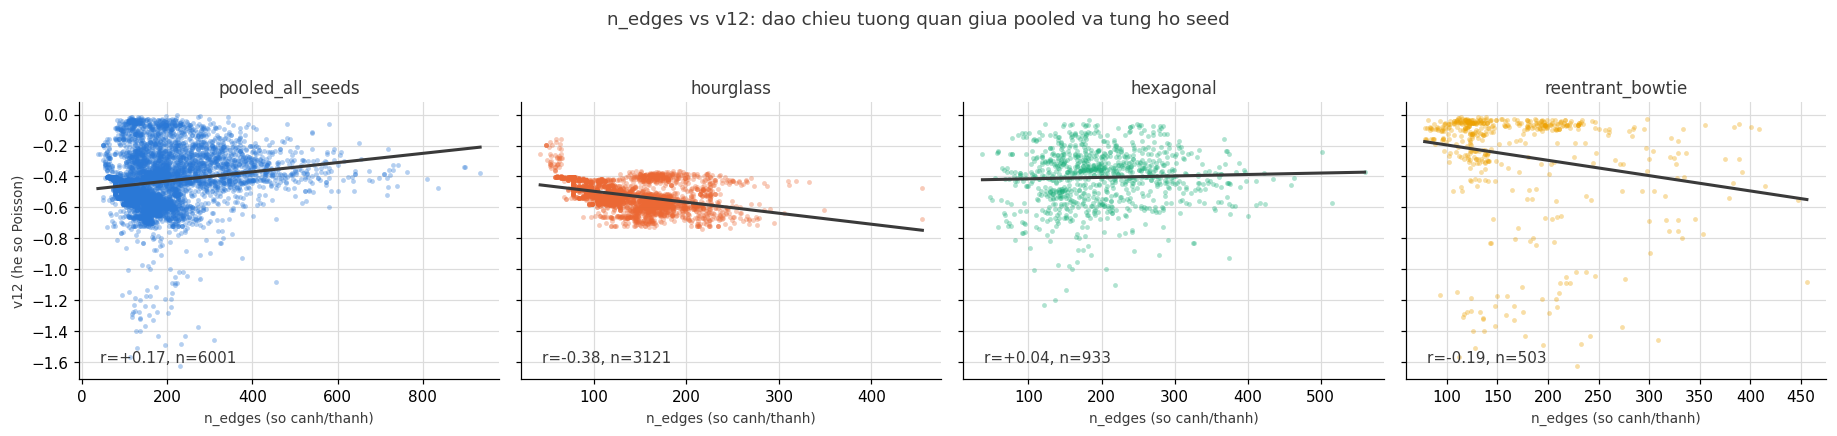

In [7]:
PANEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical, thu tu co dinh
INK, GRID = "#3a3a3a", "#dcdcdc"

panels = [("pooled_all_seeds", df)]
for s in df["seed_name"].value_counts().index[:3]:
    panels.append((s, df[df["seed_name"] == s]))

fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.0), sharey=True)
for ax, (name, g), color in zip(axes, panels, PANEL_COLORS):
    x, y = g["n_edges"].to_numpy(float), g["v12"].to_numpy(float)
    ax.scatter(x, y, s=10, color=color, alpha=0.35, linewidths=0)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, slope * xs + intercept, color=INK, linewidth=2)
    ax.text(0.05, 0.05, f"r={r:+.2f}, n={len(g)}", transform=ax.transAxes, fontsize=10, color=INK, va="bottom")
    ax.set_title(name, fontsize=11, color=INK)
    ax.set_xlabel("n_edges (so canh/thanh)", fontsize=9, color=INK)
    ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("v12 (he so Poisson)", fontsize=9, color=INK)
fig.suptitle("n_edges vs v12: dao chieu tuong quan giua pooled va tung ho seed", fontsize=12, color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 5. Kết luận

- **Hiệu ứng có thật về mặt thống kê**: các kiểm định Mann-Whitney trong từng họ lớn đều có p<0.001 (nhiều trường hợp p≈0), không phải nhiễu ngẫu nhiên với n hàng nghìn mẫu mỗi họ.
- **Nhưng KHÔNG phải yếu tố chi phối chính**: hồi quy đa biến gộp chỉ đạt R²≈0.04 - `volfrac`/họ seed vẫn quyết định phần lớn phương sai của v12. Độ mạnh hiệu ứng topology ở mức trung bình (|r|≈0.2–0.4 trong từng họ).
- **Số liệu gộp gây hiểu lầm** vì mỗi họ seed chiếm vùng giá trị v12 và cấu trúc rất khác nhau (`hourglass` áp đảo ~52% mẫu) - kết luận đúng phải đọc theo từng họ, không đọc số gộp.
- **Diễn giải vật lý khả dĩ**: ở các họ dạng "khung xoay/gấp khúc" (hourglass, circle-based), thêm thanh phụ (junction) thường tạo thêm điểm xoay/uốn góp phần tăng hiệu ứng auxetic; còn `hexagonal` (cơ chế re-entrant hình học đã cố định bởi góc cell) ít nhạy với topology phụ hơn - khớp với ghi nhận trước đó rằng `hexagonal` có hành vi yield khác biệt hẳn các seed khác.

**Giới hạn cần nêu rõ khi báo cáo**: đây là tương quan mô tả (descriptive), không phải quan hệ nhân quả đã kiểm chứng bằng can thiệp trực tiếp (vd cố định volfrac, chỉ thay đổi topology có kiểm soát). Kết quả phù hợp để đưa vào phần Discussion/giải thích cơ chế, không nên phát biểu như một quy luật thiết kế chắc chắn.

## 6. (Tùy chọn) Ghi kết quả ra đĩa

Chạy cell dưới nếu muốn lưu lại bảng đặc trưng thô + kết quả thống kê đầy đủ để dùng lại (vd cho báo cáo/paper), theo convention `outputs/phase3/reports/` đã dùng ở các phân tích trước.

In [8]:
import json

OUT_DIR = utils.PHASE3_DIR / "reports"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df.drop(columns=["idx"]).to_csv(OUT_DIR / f"geometric_features_raw_n{len(df)}.csv", index=False)

results = {"n_total": len(df), "pooled": pooled, "by_seed_class": by_seed}
with open(OUT_DIR / f"geometric_feature_influence_n{len(df)}.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

fig.savefig(utils.REPO_ROOT / "outputs" / "figures" / f"geometric_feature_influence_n_edges_vs_v12_n{len(df)}.png", dpi=150)
print("Da ghi xong.")


Da ghi xong.
